In [2]:
import os
import random
import pandas as pd

import shap

import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
import sklearn

import xgboost as xgb

from matplotlib import pyplot as plt

### Load SWE-Bench

In [3]:
swebench_df = pd.DataFrame()
swebench_path = "proxy-bench/results/swebench/"
for model_file in os.listdir(swebench_path):
    model_name = model_file[:-4]
    _df = pd.read_csv(os.path.join(swebench_path, model_file))
    _df = _df[["metadata.scores.resolved", "metadata.instance_id"]]
    # _df["metadata.scores.resolved"] = _df["metadata.scores.resolved"].astype(str).astype(float)
    _df["model"] = model_name
    swebench_df = pd.concat([swebench_df, _df], ignore_index=True)

swebench_df["metadata.scores.resolved"] = swebench_df["metadata.scores.resolved"].apply(lambda x: 0 if x == "unknown" else x)
swebench_df["metadata.scores.resolved"] = swebench_df["metadata.scores.resolved"].astype(float)

swebench_idx = swebench_df["metadata.instance_id"].unique().tolist()
model_list = swebench_df["model"].unique().tolist()

swebench_full = swebench_df.pivot_table(index="model", values="metadata.scores.resolved", aggfunc="mean")
swebench_full

,metadata.scores.resolved
model,
Claude-4-Opus,0.676000
Claude-4-Sonnet,0.648000
Claude-4.5-Sonnet,0.707415
GPT-5,0.718000
GPT-OSS-120B,0.260000
Gemini-2.5-Pro,0.536000
Gemini-3-Pro-Preview,0.742000
Kimi-K2-Instruct,0.438000
Qwen2.5-Coder-32B-Instruct,0.090000


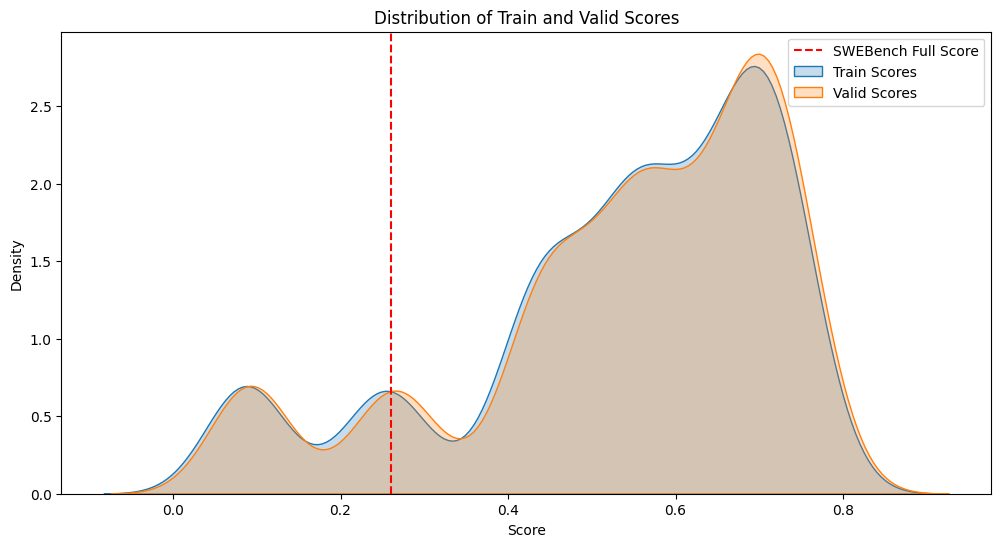

In [4]:
# model_list = ["GPT-OSS-120B"]

train_score_list = []
valid_score_list = []
for _ in range(100):
    train_idx = random.sample(list(swebench_idx), 250)
    valid_idx = list(set(swebench_idx) - set(train_idx))
    train_df = swebench_df[swebench_df["metadata.instance_id"].isin(train_idx)]
    valid_df = swebench_df[swebench_df["metadata.instance_id"].isin(valid_idx)]

    for model in model_list:
        train_model_df = train_df[train_df["model"] == model]
        valid_model_df = valid_df[valid_df["model"] == model]
    
        train_score = train_model_df["metadata.scores.resolved"].mean()
        valid_score = valid_model_df["metadata.scores.resolved"].mean()

        train_score_list.append(train_score)
        valid_score_list.append(valid_score)

# Plotting normal distribution of train and valid scores
plt.figure(figsize=(12, 6))

# Plot vertical line for swebench_full
plt.axvline(swebench_full.loc[model, "metadata.scores.resolved"], color='red', linestyle='--', label='SWEBench Full Score')

sns.kdeplot(train_score_list, label='Train Scores', fill=True)
sns.kdeplot(valid_score_list, label='Valid Scores', fill=True)
plt.title('Distribution of Train and Valid Scores')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.show()


### Load Predictor Tasks

In [5]:
task_path = "proxy-bench/data/standardized_data/"
task_list = os.listdir(task_path)

task_df = pd.DataFrame()

for task in task_list:
    task_dir = os.path.join(task_path, task)
    if not os.path.isdir(task_dir):
        continue
    # print(f"Task: {task}")
    for model in model_list:
        model_file = f"{model}.csv"
        model_path = os.path.join(task_dir, model_file)
        if not os.path.isfile(model_path):
            # print(f"  Model {model} not found for this task.")
            continue
        # print(f"  Model {model} found.")
        _df = pd.read_csv(model_path)
        _df = _df[["score"]]
        _df["idx"] = _df.index
        _df["model"] = model
        _df["task"] = task
        task_df = pd.concat([task_df, _df], ignore_index=True)

task_df = task_df[task_df["model"].isin(model_list)]

common_model_list = set(task_df["model"].unique().tolist()) & set(swebench_df["model"].unique().tolist())
superset_model_list = set(task_df["model"].unique().tolist()) | set(swebench_df["model"].unique().tolist())

# Fill zero for missing task scores for each model
for task in task_df["task"].unique():
    for model in common_model_list:
        if not ((task_df["task"] == task) & (task_df["model"] == model)).any():
            task_df = pd.concat([task_df, pd.DataFrame({"task": [task], "model": [model], "score": [0]})], ignore_index=True)


In [19]:
# # task_df[task_df["model"] == "GPT-OSS-120B"]
# # Pivot only model, task and index becomes column
# task_df_pivot = task_df.pivot_table(index="model", columns=["idx", "task"], values="score", fill_value=0)
task_df_pivot = task_df.pivot_table(index="model", columns=["task"], values="score", fill_value=0)
task_df_pivot


task,acp_gen_2shot-acp_app_gen,acp_gen_2shot-acp_areach_gen,acp_gen_2shot-acp_just_gen,acp_gen_2shot-acp_land_gen,acp_gen_2shot-acp_nexta_gen,acp_gen_2shot-acp_prog_gen,acp_gen_2shot-acp_reach_gen,acp_gen_2shot-acp_val_gen,aime25,gpqa_diamond_cot_zeroshot,...,mmlu_professional_accounting,mmlu_professional_law,mmlu_professional_medicine,mmlu_professional_psychology,mmlu_public_relations,mmlu_security_studies,mmlu_sociology,mmlu_us_foreign_policy,mmlu_virology,mmlu_world_religions
model,,,,,,,,,,,,,,,,,,,,,
Claude-4-Sonnet,0.084615,0.000000,0.084615,0.207692,0.253846,0.776923,0.046154,0.076923,0.366667,0.396465,...,0.964539,0.798566,0.970588,0.916667,0.763636,0.844898,0.945274,0.96,0.602410,0.923977
Claude-4.5-Sonnet,0.246154,0.000000,0.253846,0.261538,0.438462,0.907692,0.053846,0.184615,0.333333,0.416667,...,0.978723,0.840287,0.974265,0.942810,0.800000,0.869388,0.960199,0.97,0.584337,0.923977
GPT-5,0.492308,0.153846,1.000000,0.676923,0.815385,0.907692,0.853846,0.315385,0.900000,0.371212,...,0.833333,0.000000,0.963235,0.939542,0.845455,0.857143,0.945274,0.95,0.572289,0.953216
GPT-OSS-120B,0.007692,0.000000,0.000000,0.015385,0.023077,0.046154,0.007692,0.023077,0.766667,0.330808,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
Gemini-2.5-Pro,0.400000,0.092308,0.976923,0.515385,0.800000,0.869231,0.546154,0.784615,0.633333,0.416667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
Gemini-3-Pro-Preview,0.384615,0.015385,0.607692,0.269231,0.384615,0.846154,0.123077,0.238462,0.900000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
Kimi-K2-Instruct,0.153846,0.015385,0.476923,0.346154,0.400000,0.784615,0.284615,0.384615,0.000000,0.282828,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
Qwen3-Coder-480B-A35B-Instruct,0.146154,0.007692,0.630769,0.276923,0.415385,0.730769,0.346154,0.476923,0.466667,0.361111,...,0.897163,0.679922,0.948529,0.883987,0.718182,0.800000,0.895522,0.93,0.463855,0.871345
o3,0.538462,0.123077,0.946154,0.753846,0.838462,0.884615,0.861538,0.307692,0.866667,0.383838,...,0.815603,0.806389,0.952206,0.926471,0.845455,0.840816,0.935323,0.96,0.572289,0.941520


In [7]:
performance = {
    "Claude-4.5-Opus": 74.40,
    "Gemini-3-Pro-Preview": 74.20,
    # "GPT-5.2 (2025-12-11) (high reasoning)": 71.80,
    "Claude-4.5-Sonnet": 70.60,
    # "GPT-5.2 (2025-12-11)": 69.00,
    "Claude-4-Opus": 67.60,
    # "GPT-5.1-codex (medium reasoning)": 66.00,
    # "GPT-5.1 (2025-11-13) (medium reasoning)": 66.00,
    "GPT-5": 65.00,
    "Claude-4-Sonnet": 64.93,
    # "Kimi K2 Thinking": 63.40,
    # "Minimax M2": 61.00,
    # "DeepSeek V3.2 Reasoner": 60.00,
    "GPT-5-mini": 59.80,
    "o3": 58.40,
    # "Devstral small (2512)": 56.40,
    "Qwen3-Coder-480B-A35B-Instruct": 55.40,
    # "GLM-4.6 (T=1)": 55.40,
    # "GLM-4.5 (2025-08-22)": 54.20,
    # "Devstral (2512)": 53.80,
    "Gemini-2.5-Pro": 53.60,
    # "Claude 3.7 Sonnet (20250219)": 52.80,
    "o4-mini": 45.00,
    "Kimi-K2-Instruct": 43.80,
    # "GPT-4.1 (2025-04-14)": 39.58,
    "GPT-5-nano": 34.80,
    "Gemini-2.5-Flash": 28.73,
    "GPT-OSS-120B": 26.00,
    # "GPT-4.1-mini (2025-04-14)": 23.94,
    "GPT-4o": 21.62,
    "Llama-4-Maverick-17B-128E-Instruct-FP8": 21.04,
    "Gemini-2.0-Flash": 13.52,
    # "Llama 4 Scout Instruct": 9.06,
    # "Qwen2.5-Coder 32B Instruct": 9.00,
}

test_model_list = set(performance.keys()) & set(task_df["model"].unique().tolist()) - set(swebench_df["model"].unique().tolist())

In [8]:
set(swebench_df["model"].unique().tolist())

{'Claude-4-Opus',
 'Claude-4-Sonnet',
 'Claude-4.5-Sonnet',
 'GPT-5',
 'GPT-OSS-120B',
 'Gemini-2.5-Pro',
 'Gemini-3-Pro-Preview',
 'Kimi-K2-Instruct',
 'Qwen2.5-Coder-32B-Instruct',
 'Qwen3-Coder-480B-A35B-Instruct',
 'o3',
 'o4-mini'}

### Shap Analysis

10

### Fit Predictor

In [ ]:
Y_hat = []
Y = []
rmse_list = []

for model in model_list:

    print(f"Evaluating model: {model}")

    leave_out_df = swebench_df[
            (swebench_df["model"]!= model) & (swebench_df["model"].isin(common_model_list))
        ]
    
    train_idx = random.sample(list(swebench_idx), 250)
    valid_idx = list(set(swebench_idx) - set(train_idx))

    train_swebench_df = leave_out_df[
        leave_out_df["metadata.instance_id"].isin(train_idx)
    ]

    valid_swebench_df = leave_out_df[
        leave_out_df["metadata.instance_id"].isin(valid_idx)
    ]
    
    train_x = task_df[
        (task_df["model"] != model) & (task_df["model"].isin(common_model_list))
    # ].pivot_table(index="model", columns=["idx", "task"], values="score", fill_value=0)
    ].pivot_table(index="task", columns="model", values="score", aggfunc="mean")
    train_x = train_x.transpose()
    train_x = train_x.fillna(0)

    train_y = train_swebench_df.pivot_table(index="model", values="metadata.scores.resolved", aggfunc="mean")
    valid_y = valid_swebench_df.pivot_table(index="model", values="metadata.scores.resolved", aggfunc="mean")

    test_x = task_df[
        (task_df["model"] == model) & (task_df["model"].isin(common_model_list))
    # ].pivot_table(index="model", columns=["idx", "task"], values="score", fill_value=0)
    ].pivot_table(index="task", columns="model", values="score", aggfunc="mean")
    test_x = test_x.transpose()
    test_x = test_x.fillna(0)

    # # Fill features in train_x that are not in test_x with zero
    # missing_cols = list(set(train_x.columns) - set(test_x.columns))
    # if missing_cols:
    #     missing_data = pd.DataFrame(0, index=test_x.index, columns=missing_cols)
    #     test_x = pd.concat([test_x, missing_data], axis=1)

    # Ensure the column order in test_x matches train_x
    # test_x = test_x[train_x.columns]

    if test_x.shape[0] == 0:
        print(f"No test data for model {model}, skipping.")
        continue

    test_y = swebench_df[
        swebench_df["model"] == model
    ].pivot_table(index="model", values="metadata.scores.resolved", aggfunc="mean")

    # model = RandomForestRegressor(
    #     n_estimators=40,
    #     random_state=42,
    #     criterion="friedman_mse",
    #     )
    m = sklearn.linear_model.LinearRegression()
    m.fit(train_x, train_y.values.ravel())

    # param_grid = {
    #     'n_estimators': [200, 500],
    #     'max_depth': [5, 7, 10],
    #     'learning_rate': [0.01, 0.05, 0.1],
    #     # 'subsample': [0.7, 0.8, 0.9],
    #     'colsample_bytree': [0.7, 0.8, 0.9],
    #     'min_child_weight': [1, 3, 5],
    # }

    # model = xgb.XGBRegressor(tree_method="hist")

    # grid_search = GridSearchCV(
    #     model,
    #     param_grid,
    #     cv=2,
    #     scoring='neg_root_mean_squared_log_error',
    #     n_jobs=128,
    #     verbose=4
    # )

    # # grid_search.fit(X, y)
    # # Fit the model on training data
    # grid_search.fit(train_x, train_y.values.ravel())
    # print(grid_search.best_params_)
    # model.set_params(**grid_search.best_params_)
    # Validate the model
    test_predictions = m.predict(test_x)
    rmse = root_mean_squared_error(test_y, test_predictions)
    rmse_list.append(rmse)

    print(f"Test RMSE: {rmse}, Predictions: {test_predictions}, Actual: {test_y.values.ravel()}")
    # break
    Y_hat.append(test_predictions[0])
    Y.append(test_y.values[0][0])

    print(model_name)
    if model == "Claude-4-Sonnet":
        break

print(f"Overall RMSE: {root_mean_squared_error(Y, Y_hat)}")

Evaluating model: Claude-4.5-Sonnet
Test RMSE: 0.015751086798779457, Predictions: [0.69166374], Actual: [0.70741483]
LinearRegression()
Evaluating model: Qwen3-Coder-480B-A35B-Instruct
Test RMSE: 0.13078036310528418, Predictions: [0.68478036], Actual: [0.554]
LinearRegression()
Evaluating model: o4-mini
Test RMSE: 0.10304978841233076, Predictions: [0.55304979], Actual: [0.45]
LinearRegression()
Evaluating model: GPT-5
Test RMSE: 0.07999551986142084, Predictions: [0.63800448], Actual: [0.718]
LinearRegression()
Evaluating model: o3
Test RMSE: 0.13016882709222, Predictions: [0.71416883], Actual: [0.584]
LinearRegression()
Evaluating model: Gemini-3-Pro-Preview
Test RMSE: 0.28692622943858237, Predictions: [0.45507377], Actual: [0.742]
LinearRegression()
Evaluating model: Claude-4-Sonnet
Test RMSE: 0.011337677696410364, Predictions: [0.63666232], Actual: [0.648]
LinearRegression()
Evaluating model: Claude-4-Opus
No test data for model Claude-4-Opus, skipping.
Evaluating model: Gemini-2.5-P

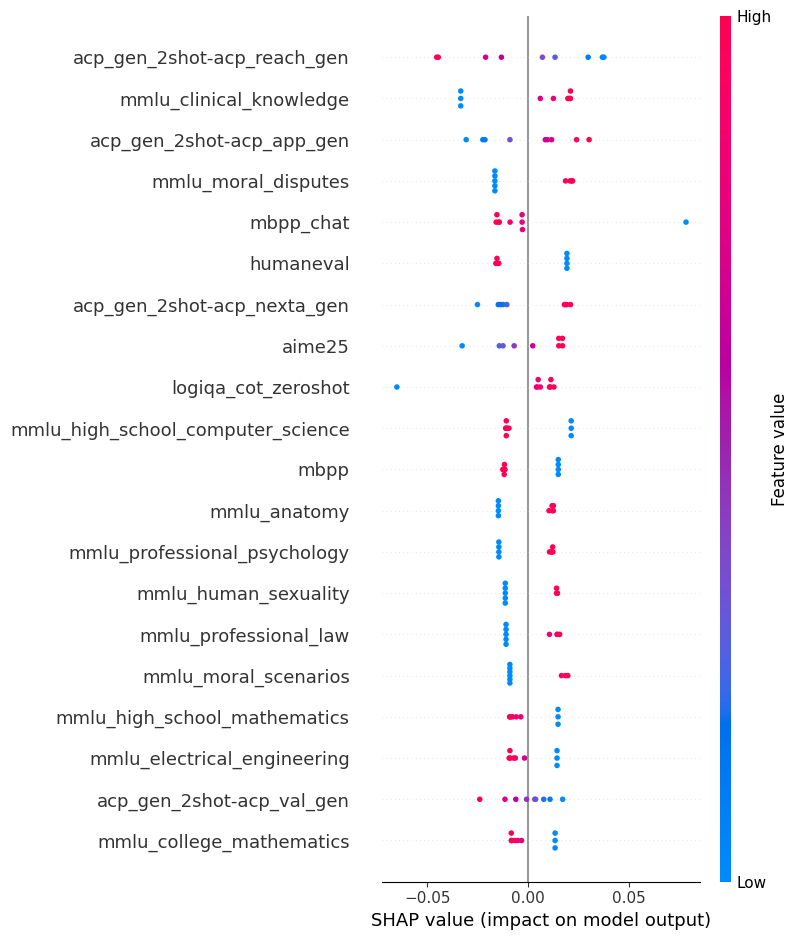

In [24]:
# Analyze feature importance using SHAP values
explainer = shap.Explainer(model, train_x)
shap_values = explainer(train_x)
shap.summary_plot(shap_values, train_x)


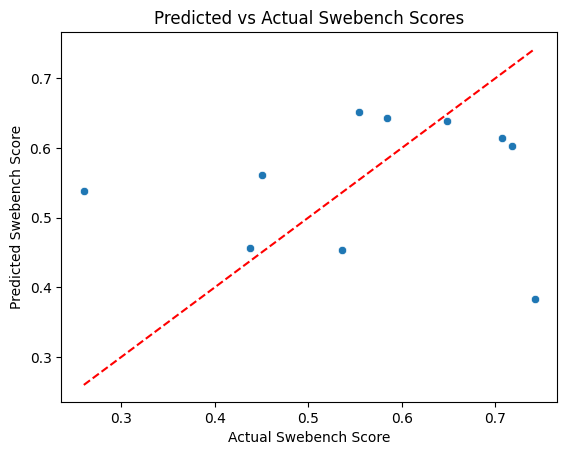

In [11]:
sns.scatterplot(x=Y, y=Y_hat)
# Add a diagonal line for reference
plt.plot([min(Y), max(Y)], [min(Y), max(Y)], 'r--')
plt.xlabel("Actual Swebench Score")
plt.ylabel("Predicted Swebench Score")
plt.title("Predicted vs Actual Swebench Scores")
plt.show()

In [224]:
train_x

task,acp_gen_2shot-acp_app_gen,acp_gen_2shot-acp_areach_gen,acp_gen_2shot-acp_just_gen,acp_gen_2shot-acp_land_gen,acp_gen_2shot-acp_nexta_gen,acp_gen_2shot-acp_prog_gen,acp_gen_2shot-acp_reach_gen,acp_gen_2shot-acp_val_gen,aime25,gpqa_diamond_cot_zeroshot,...,mmlu_professional_accounting,mmlu_professional_law,mmlu_professional_medicine,mmlu_professional_psychology,mmlu_public_relations,mmlu_security_studies,mmlu_sociology,mmlu_us_foreign_policy,mmlu_virology,mmlu_world_religions
model,,,,,,,,,,,,,,,,,,,,,
Claude-4-Sonnet,0.084615,0.000000,0.084615,0.207692,0.253846,0.776923,0.046154,0.076923,0.366667,0.396465,...,0.964539,0.798566,0.970588,0.916667,0.763636,0.844898,0.945274,0.96,0.602410,0.923977
GPT-5,0.492308,0.153846,1.000000,0.676923,0.815385,0.907692,0.853846,0.315385,0.900000,0.371212,...,0.833333,0.000000,0.963235,0.939542,0.845455,0.857143,0.945274,0.95,0.572289,0.953216
GPT-OSS-120B,0.007692,0.000000,0.000000,0.015385,0.023077,0.046154,0.007692,0.023077,0.766667,0.330808,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
Gemini-2.5-Pro,0.400000,0.092308,0.976923,0.515385,0.800000,0.869231,0.546154,0.784615,0.633333,0.416667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
Gemini-3-Pro-Preview,0.384615,0.015385,0.607692,0.269231,0.384615,0.846154,0.123077,0.238462,0.900000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
Kimi-K2-Instruct,0.153846,0.015385,0.476923,0.346154,0.400000,0.784615,0.284615,0.384615,0.000000,0.282828,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
Qwen3-Coder-480B-A35B-Instruct,0.146154,0.007692,0.630769,0.276923,0.415385,0.730769,0.346154,0.476923,0.466667,0.361111,...,0.897163,0.679922,0.948529,0.883987,0.718182,0.800000,0.895522,0.93,0.463855,0.871345
o3,0.538462,0.123077,0.946154,0.753846,0.838462,0.884615,0.861538,0.307692,0.866667,0.383838,...,0.815603,0.806389,0.952206,0.926471,0.845455,0.840816,0.935323,0.96,0.572289,0.941520
o4-mini,0.376923,0.100000,0.238462,0.607692,0.807692,0.769231,0.623077,0.569231,0.866667,0.343434,...,0.578014,0.000000,0.000000,0.000000,0.709091,0.755102,0.900498,0.91,0.560241,0.812865


In [ ]:
mbpp_df = pd.DataFrame()
mbpp_path = "proxy-bench/data/standardized_data/mbpp_chat/"
for model_file in os.listdir(mbpp_path):
    model_name = model_file[:-4]
    _df = pd.read_csv(os.path.join(mbpp_path, model_file))
    _df = _df[["score"]]
    _df["idx"] = _df.index
    _df["model"] = model_name
    mbpp_df = pd.concat([mbpp_df, _df], ignore_index=True)

,metadata.scores.resolved,metadata.instance_id,model
79,1,astropy__astropy-7166,Claude-4.5-Sonnet
515,0,astropy__astropy-7166,Qwen3-Coder-480B-A35B-Instruct
1091,1,astropy__astropy-7166,o4-mini
1549,1,astropy__astropy-7166,GPT-5
2015,1,astropy__astropy-7166,o3
2655,1,astropy__astropy-7166,Gemini-3-Pro-Preview
3061,1,astropy__astropy-7166,Claude-4-Sonnet
3510,1,astropy__astropy-7166,Claude-4-Opus
4033,1,astropy__astropy-7166,Gemini-2.5-Pro
4516,0,astropy__astropy-7166,Qwen2.5-Coder-32B-Instruct


In [48]:
corr_df = pd.read_csv("proxy-bench/analysis/outputs/mbpp_swebench_correlation_pearson.csv")

In [51]:
# heatmap
sns.heatmap(corr_df.pivot(index="model_x", columns="model_y", values="correlation"), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

KeyError: 'model_x'